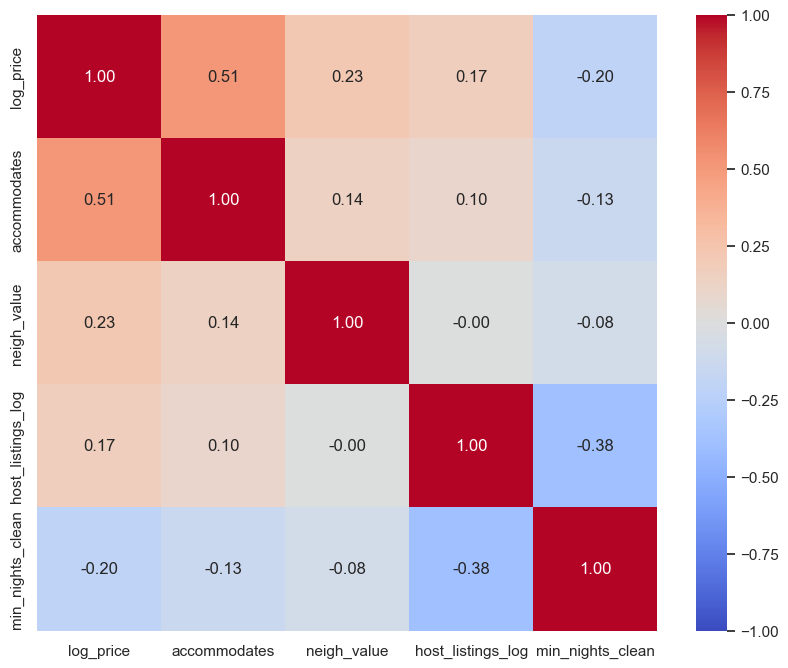

In [17]:
import pandas as pd
import numpy as np
if 'calculated_host_listings_count' in df.columns:
    # Dağılım çok uçuk olduğu için (1 vs 100) logaritma alalım
    df['host_listings_log'] = np.log1p(df['calculated_host_listings_count'].fillna(1))
else:
    df['host_listings_log'] = 0

# 2. MİNİMUM KONAKLAMA (Kısa vs Uzun Dönem)
# 30 günden fazla kuralı olanlar genelde daha ucuzdur.
if 'minimum_nights' in df.columns:
    # Aşırı uç değerleri (örn: 1000 gün) baskılamak için 30 ile sınırlayabiliriz veya log alabiliriz
    df['min_nights_clean'] = df['minimum_nights'].clip(upper=30)
else:
    df['min_nights_clean'] = 1

# 3. SPESİFİK OLANAKLAR (Klima, Güvenlik, Havuz)
# Olanak sayısından (count) ziyade "nitelik" arıyoruz.
# (Amenities sütunu string formatındaysa)
if 'amenities' in df.columns:
    amenities_str = df['amenities'].astype(str).str.lower()
    
    # Klima var mı? (Yazın fiyatı çok etkiler, boyuttan bağımsızdır)
    df['has_ac'] = amenities_str.apply(lambda x: 1 if 'air conditioning' in x or 'klima' in x else 0)
    
    # Güvenlik/Resepsiyon var mı? (Site içi mi?)
    df['has_security'] = amenities_str.apply(lambda x: 1 if 'security' in x or 'doorman' in x or 'guard' in x else 0)
else:
    df['has_ac'] = 0
    df['has_security'] = 0

# 4. ANINDA REZERVASYON (Kolaylık)
if 'instant_bookable' in df.columns:
    df['instant_bookable_binary'] = df['instant_bookable'].map({'t': 1, 'f': 0}).fillna(0)
else:
    df['instant_bookable_binary'] = 0


# --- KORELASYON KONTROLÜ (BAĞIMSIZLIK TESTİ) ---
independent_candidates = [
    'log_price',            # Hedef
    'accommodates',         # Baz 1 (Kapasite)
    'neigh_value',          # Baz 2 (Konum)
    'host_listings_log',    # Aday 1
    'min_nights_clean'
]

# Sadece var olanları seç
cols_check = [c for c in independent_candidates if c in df.columns]

plt.figure(figsize=(10, 8))
# Korelasyonu hesapla
corr = df[cols_check].corr()

# Maske: Sadece accommodates ve neigh_value ile olan ilişkilere odaklanalım
# (Tüm haritaya bakmak yerine sadece ilgili satırlara bakmak daha net olur)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.show()